In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_parquet('cleaned_dataset.parquet')

In [3]:
df.head()

,Features,Category
0,hr administratormarketing associate hr adminis...,Hr
1,hr specialist u hr operation summary versatile...,Hr
2,hr director summary year experience recruiting...,Hr
3,hr specialist summary dedicated driven dynamic...,Hr
4,hr manager skill highlight hr skill hr departm...,Hr


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Features  2484 non-null   object
 1   Category  2484 non-null   object
dtypes: object(2)
memory usage: 38.9+ KB


In [5]:
# category is the target label 
# encoding category using labelencoder

In [6]:
#from sklearn.preprocessing import LabelEncoder
#le=LabelEncoder()
 

In [7]:
#le.fit(df['Category'])
#df['Category']=le.transform(df['Category'])

In [8]:
df.head()

,Features,Category
0,hr administratormarketing associate hr adminis...,Hr
1,hr specialist u hr operation summary versatile...,Hr
2,hr director summary year experience recruiting...,Hr
3,hr specialist summary dedicated driven dynamic...,Hr
4,hr manager skill highlight hr skill hr departm...,Hr


In [9]:
df['Category'].unique()

array(['Hr', 'Designer', 'Information-Technology', 'Teacher', 'Advocate',
       'Business-Development', 'Healthcare', 'Fitness', 'Agriculture',
       'Bpo', 'Sales', 'Consultant', 'Digital-Media', 'Automobile',
       'Chef', 'Finance', 'Apparel', 'Engineering', 'Accountant',
       'Construction', 'Public-Relations', 'Banking', 'Arts', 'Aviation'],
      dtype=object)

In [10]:
#train-test split

In [11]:
from sklearn.model_selection import train_test_split

x=df['Features']
y=df['Category']

x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=42)

## TF-IDF

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [13]:
tfidf=TfidfVectorizer()
x_train_tfid=tfidf.fit_transform(x_train)
x_test_tfid=tfidf.transform(x_test)

In [14]:
x_train_tfid

<1987x38503 sparse matrix of type '<class 'numpy.float64'>'
	with 598756 stored elements in Compressed Sparse Row format>

In [15]:
x_train_tfid.shape

(1987, 38503)

## Model Training

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix ,precision_score, recall_score, f1_score

In [17]:
#1.Logistic
lr=LogisticRegression()
lr.fit(x_train_tfid,y_train)
lr_pred=lr.predict(x_test_tfid)

In [18]:
#from sklearn.preprocessing import LabelEncoder

# assuming you used le = LabelEncoder()
#pred_labels = le.inverse_transform(lr_pred)

#actual_labels = le.inverse_transform(y_test)

#print(pred_labels[:10])
#print(actual_labels[:10])

In [19]:
print("Predicted:", lr_pred[:10])
print("Actual   :", y_test[:10].values)

Predicted: ['Teacher' 'Digital-Media' 'Construction' 'Chef' 'Banking' 'Healthcare'
 'Designer' 'Business-Development' 'Teacher' 'Designer']
Actual   : ['Teacher' 'Digital-Media' 'Construction' 'Chef' 'Banking'
 'Business-Development' 'Designer' 'Business-Development' 'Teacher'
 'Designer']


In [20]:
#2 random forest
rf=RandomForestClassifier(n_estimators=150,class_weight='balanced')
rf.fit(x_train_tfid,y_train)
rf_pred=rf.predict(x_test_tfid)

In [21]:
print("Predicted:", rf_pred[:10])
print("Actual   :", y_test[:10].values)

Predicted: ['Teacher' 'Digital-Media' 'Construction' 'Chef' 'Banking'
 'Business-Development' 'Designer' 'Healthcare' 'Teacher' 'Designer']
Actual   : ['Teacher' 'Digital-Media' 'Construction' 'Chef' 'Banking'
 'Business-Development' 'Designer' 'Business-Development' 'Teacher'
 'Designer']


In [22]:
#3 naive baiyes
nb=MultinomialNB()
nb.fit(x_train_tfid, y_train)
nb_pred=nb.predict(x_test_tfid)

In [23]:
print("Predicted:", nb_pred[:10])
print("Actual   :", y_test[:10].values)

Predicted: ['Public-Relations' 'Public-Relations' 'Construction' 'Chef' 'Banking'
 'Healthcare' 'Designer' 'Business-Development' 'Teacher' 'Designer']
Actual   : ['Teacher' 'Digital-Media' 'Construction' 'Chef' 'Banking'
 'Business-Development' 'Designer' 'Business-Development' 'Teacher'
 'Designer']


In [24]:
#4 linear svm
svm=LinearSVC(class_weight='balanced',dual='auto')
svm.fit(x_train_tfid, y_train)
svm_pred = svm.predict(x_test_tfid)

In [25]:
print("Predicted:", svm_pred[:10])
print("Actual   :", y_test[:10].values)

Predicted: ['Teacher' 'Digital-Media' 'Construction' 'Chef' 'Banking'
 'Public-Relations' 'Designer' 'Business-Development' 'Teacher' 'Designer']
Actual   : ['Teacher' 'Digital-Media' 'Construction' 'Chef' 'Banking'
 'Business-Development' 'Designer' 'Business-Development' 'Teacher'
 'Designer']


## Evaluation

In [26]:
#confusion matrix
cm_lr=confusion_matrix(y_test, lr_pred)
cm_rf=confusion_matrix(y_test, rf_pred)
cm_nb=confusion_matrix(y_test, nb_pred)
cm_svm=confusion_matrix(y_test, svm_pred)

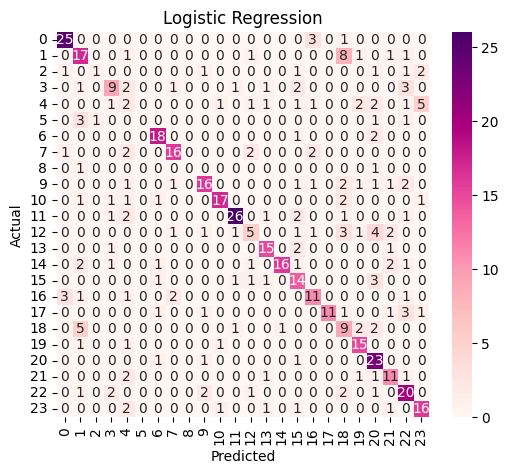

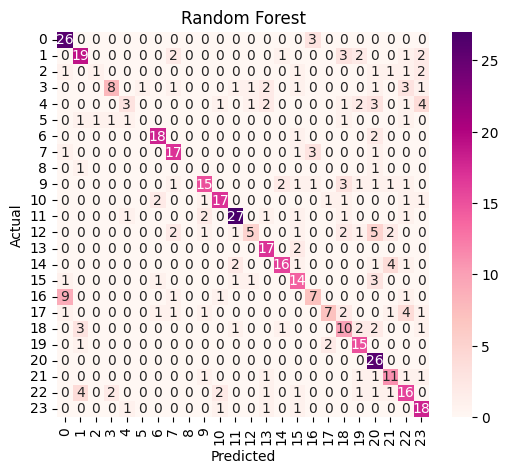

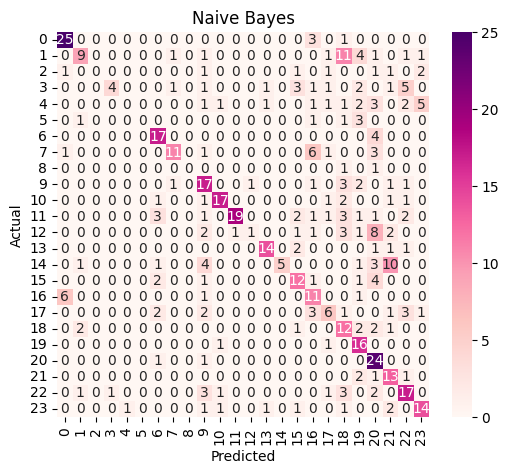

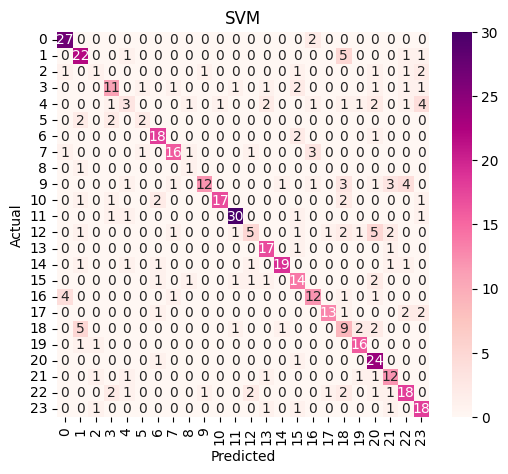

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cm(cm, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d',cmap='RdPu')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(cm_lr, "Logistic Regression")
plot_cm(cm_rf, "Random Forest")
plot_cm(cm_nb, "Naive Bayes")
plot_cm(cm_svm, "SVM")

In [28]:
#Accuracy,recall,precision,f1
#1. logistic
lr_acc = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred, average='weighted')
lr_rec = recall_score(y_test, lr_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

print("Accuracy:", lr_acc)
print("Precision:", lr_prec)
print("Recall:", lr_rec)
print("F1 Score:", lr_f1)

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Accuracy: 0.6297786720321932
Precision: 0.6400601380699236
Recall: 0.6297786720321932
F1 Score: 0.6230501655256423

Classification Report:
                        precision    recall  f1-score   support

            Accountant       0.83      0.86      0.85        29
              Advocate       0.52      0.57      0.54        30
           Agriculture       0.50      0.12      0.20         8
               Apparel       0.56      0.45      0.50        20
                  Arts       0.12      0.11      0.11        18
            Automobile       0.00      0.00      0.00         6
              Aviation       0.78      0.86      0.82        21
               Banking       0.76      0.70      0.73        23
                   Bpo       0.00      0.00      0.00         2
  Business-Development       0.73      0.59      0.65        27
                  Chef       0.85      0.71      0.77        24
          Construction       0.87      0.76      0.81        34
            Consultant      

C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [29]:
rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='weighted')
rf_rec = recall_score(y_test, rf_pred, average='weighted')
rf_f1 = f1_score(y_test, rf_pred, average='weighted')

print("Accuracy:", rf_acc)
print("Precision:", rf_prec)
print("Recall:", rf_rec)
print("F1 Score:", rf_f1)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy: 0.6297786720321932
Precision: 0.630184375545025
Recall: 0.6297786720321932
F1 Score: 0.6088256189701535

Classification Report:
                        precision    recall  f1-score   support

            Accountant       0.67      0.90      0.76        29
              Advocate       0.66      0.63      0.64        30
           Agriculture       0.50      0.12      0.20         8
               Apparel       0.73      0.40      0.52        20
                  Arts       0.50      0.17      0.25        18
            Automobile       0.00      0.00      0.00         6
              Aviation       0.82      0.86      0.84        21
               Banking       0.68      0.74      0.71        23
                   Bpo       0.00      0.00      0.00         2
  Business-Development       0.71      0.56      0.62        27
                  Chef       0.77      0.71      0.74        24
          Construction       0.82      0.79      0.81        34
            Consultant       

C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [30]:
nb_acc = accuracy_score(y_test, nb_pred)
nb_prec = precision_score(y_test, nb_pred, average='weighted')
nb_rec = recall_score(y_test, nb_pred, average='weighted')
nb_f1 = f1_score(y_test, nb_pred, average='weighted')

print("Accuracy:", nb_acc)
print("Precision:", nb_prec)
print("Recall:", nb_rec)
print("F1 Score:", nb_f1)

print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.5311871227364185
Precision: 0.5761469411020438
Recall: 0.5311871227364185
F1 Score: 0.5005888268106876

Classification Report:
                        precision    recall  f1-score   support

            Accountant       0.76      0.86      0.81        29
              Advocate       0.64      0.30      0.41        30
           Agriculture       0.00      0.00      0.00         8
               Apparel       0.80      0.20      0.32        20
                  Arts       0.00      0.00      0.00        18
            Automobile       0.00      0.00      0.00         6
              Aviation       0.63      0.81      0.71        21
               Banking       0.79      0.48      0.59        23
                   Bpo       0.00      0.00      0.00         2
  Business-Development       0.44      0.63      0.52        27
                  Chef       0.81      0.71      0.76        24
          Construction       0.95      0.56      0.70        34
            Consultant      

C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ACER\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [31]:
svm_acc = accuracy_score(y_test, svm_pred)
svm_prec = precision_score(y_test, svm_pred, average='weighted')
svm_rec = recall_score(y_test, svm_pred, average='weighted')
svm_f1 = f1_score(y_test, svm_pred, average='weighted')

print("Accuracy:", svm_acc)
print("Precision:", svm_prec)
print("Recall:", svm_rec)
print("F1 Score:", svm_f1)

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

Accuracy: 0.6780684104627767
Precision: 0.68532951150961
Recall: 0.6780684104627767
F1 Score: 0.6684577103862375

Classification Report:
                        precision    recall  f1-score   support

            Accountant       0.82      0.93      0.87        29
              Advocate       0.65      0.73      0.69        30
           Agriculture       0.25      0.12      0.17         8
               Apparel       0.61      0.55      0.58        20
                  Arts       0.33      0.17      0.22        18
            Automobile       0.50      0.33      0.40         6
              Aviation       0.75      0.86      0.80        21
               Banking       0.80      0.70      0.74        23
                   Bpo       0.25      0.50      0.33         2
  Business-Development       0.86      0.44      0.59        27
                  Chef       0.94      0.71      0.81        24
          Construction       0.88      0.88      0.88        34
            Consultant       0

In [32]:
#selecting best model
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Naive Bayes", "SVM"],
    "Accuracy": [lr_acc, rf_acc, nb_acc, svm_acc],
    "Precision": [lr_prec, rf_prec, nb_prec, svm_prec],
    "Recall": [lr_rec, rf_rec, nb_rec, svm_rec],
    "F1 Score": [lr_f1, rf_f1, nb_f1, svm_f1]
})

results_df = results_df.sort_values(by="F1 Score", ascending=False)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
3                  SVM  0.678068   0.685330  0.678068  0.668458
0  Logistic Regression  0.629779   0.640060  0.629779  0.623050
1        Random Forest  0.629779   0.630184  0.629779  0.608826
2          Naive Bayes  0.531187   0.576147  0.531187  0.500589


SVM performs better than other models 

### Fine Tuning svm

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
param_grid = {'C': [0.1, 1, 5, 10]}
gridsvm=GridSearchCV(LinearSVC(class_weight='balanced', dual='auto'),param_grid,cv=3,scoring='f1_weighted')
gridsvm.fit(x_train_tfid, y_train)
print(gridsvm.best_params_)

{'C': 5}


In [35]:
best_svm = gridsvm.best_estimator_

In [36]:
svm_pred = best_svm.predict(x_test_tfid)

print("Accuracy:", accuracy_score(y_test, svm_pred))
print("F1 Score:", f1_score(y_test, svm_pred, average='weighted'))

Accuracy: 0.676056338028169
F1 Score: 0.6691189439103105


there is no drastic change this means the model was already optimized

In [39]:
import joblib
joblib.dump(best_svm, "svm_model.joblib")
joblib.dump(tfidf, "tfidf.joblib")

['tfidf.joblib']